In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [13]:
df = pd.read_csv("/kaggle/input/datasets/vijayaadithyanvg/car-price-predictionused-cars/car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [14]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (301, 9)

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate Rows: 2


In [15]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (299, 9)


In [16]:
current_year = 2025

df["Car_Age"] = current_year - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


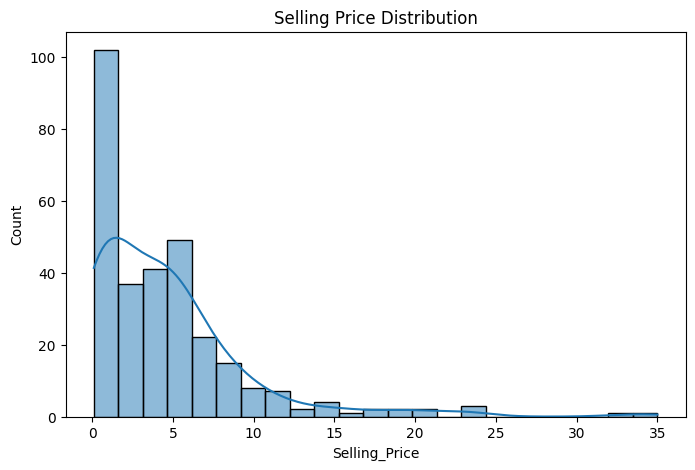

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Selling Price Distribution")

plt.show()

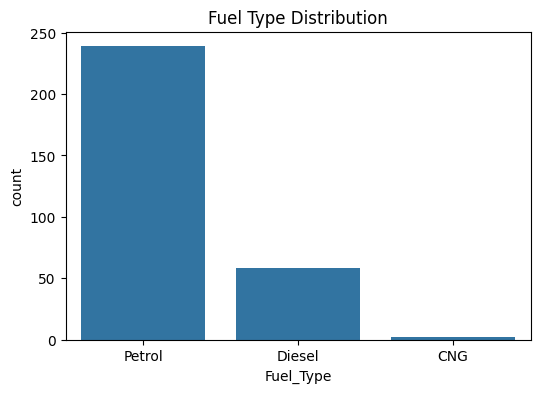

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x="Fuel_Type", data=df)

plt.title("Fuel Type Distribution")

plt.show()

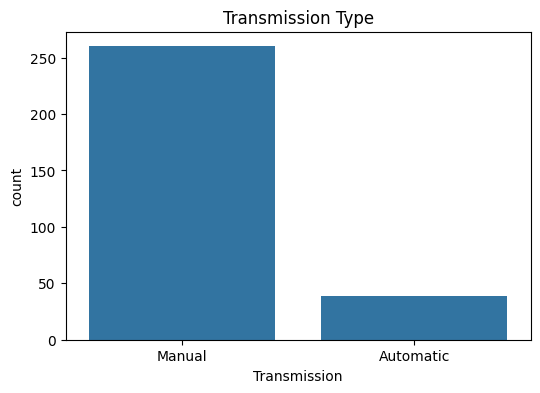

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="Transmission", data=df)

plt.title("Transmission Type")

plt.show()

In [20]:
df = df.drop(["Car_Name"], axis=1)

df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [21]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,11,False,True,False,True
1,2013,4.75,9.54,43000,0,12,True,False,False,True
2,2017,7.25,9.85,6900,0,8,False,True,False,True
3,2011,2.85,4.15,5200,0,14,False,True,False,True
4,2014,4.60,6.87,42450,0,11,True,False,False,True


In [22]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [25]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[ 9.3377  8.316   0.4404  6.938  18.2805]


In [26]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.5231800000000009


In [27]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 3.7164587220004663


In [28]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.46409324076855507


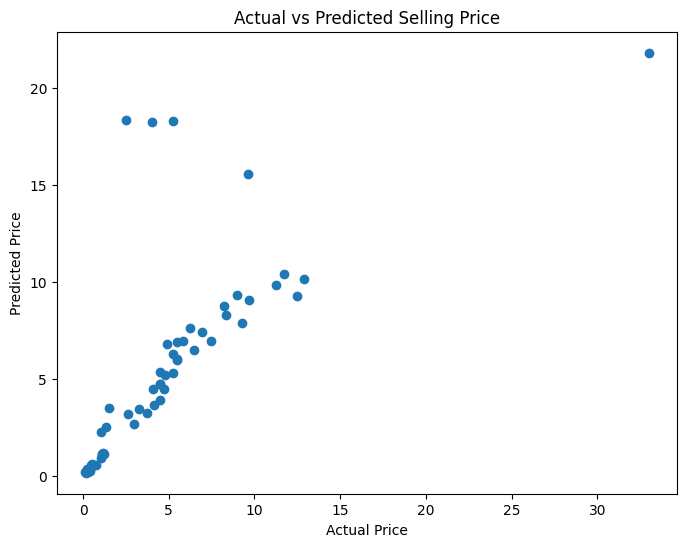

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Selling Price")

plt.show()

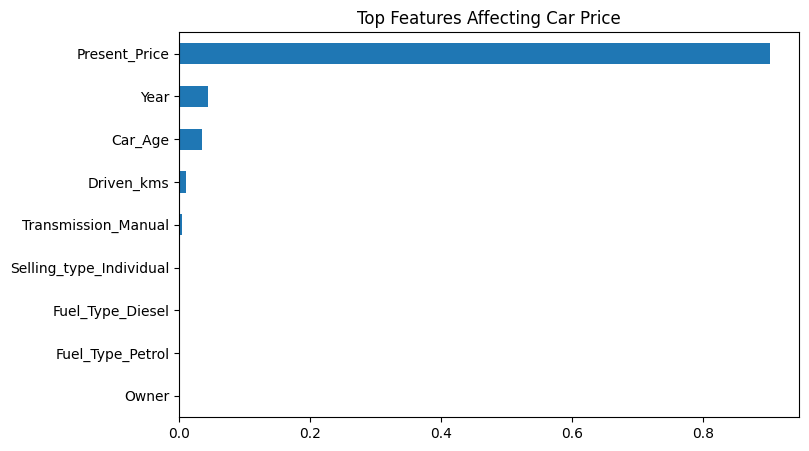

In [30]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Features Affecting Car Price")

plt.show()

In [31]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 3.5995000000000017
